# Model Explainability for Fraud Detection

This notebook analyzes how the trained model detects fraudulent transactions using:

- Feature Importance
- SHAP (SHapley Additive Explanations)

These techniques help interpret model predictions and identify the most influential variables.

In [1]:
!pip install shap

You should consider upgrading via the '/Users/juanpablodavilamartinez/credit-risk-finance/venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import shap
import joblib

In [3]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

In [4]:
model = joblib.load("../models/xgboost_fraud_model.pkl")

In [5]:
importances = pd.Series(
    model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print(importances.head(10))

V14              0.569139
V4               0.061660
V12              0.042956
V8               0.026488
V20              0.018046
V7               0.016873
V27              0.016857
Amount_scaled    0.016654
V13              0.016573
V28              0.016307
dtype: float32


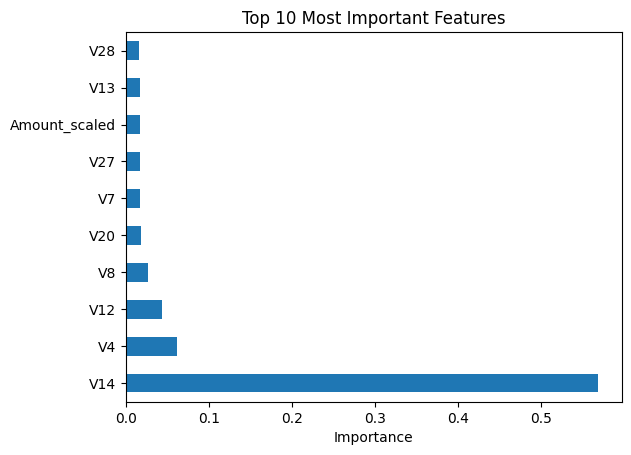

In [6]:
importances.head(10).plot(kind="barh")

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.show()

In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

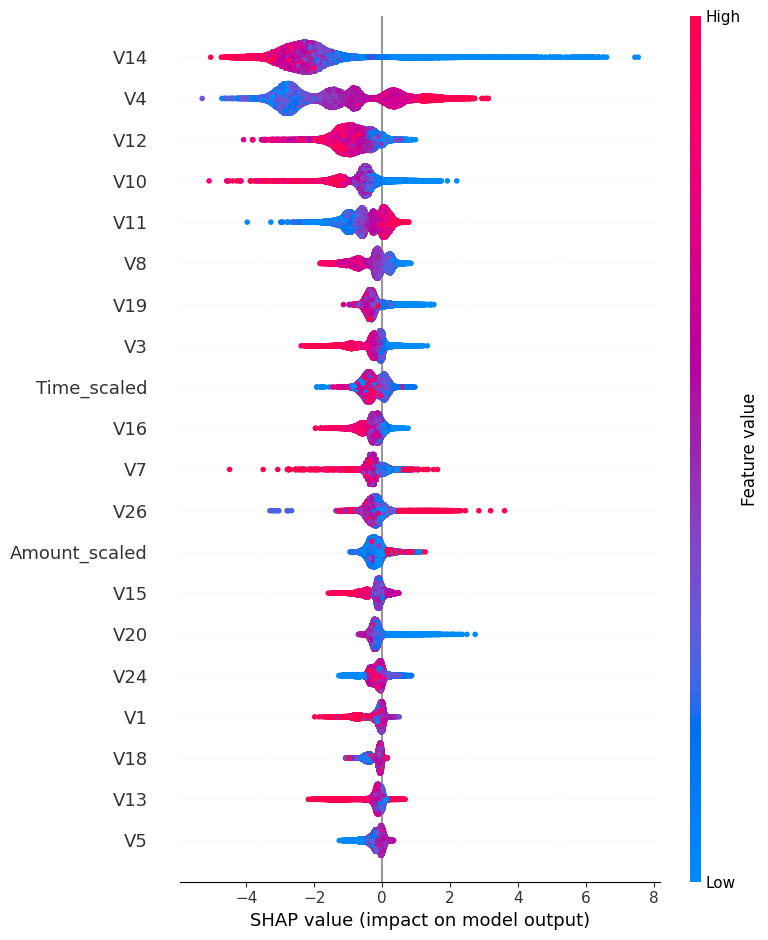

In [8]:
shap.summary_plot(shap_values, X_test)

### Interpretation

SHAP analysis reveals that several PCA-transformed variables such as V12, V10, and V11 strongly influence fraud predictions.

Low values of these components tend to increase the probability of fraud, indicating anomalous transaction patterns captured by the PCA transformation.